# Confidence Weighted Fidelity

This notebook computes confidence-weighted fidelity across various datasets and models.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Synthetic Dataset Generation

In this section, we define generators for a variety of 2D synthetic datasets (XOR, Checkerboard, Spiral, Warped Blobs, Linear Blobs, Gaussian Overlap, Moons, Circles) and a 10-dimensional classification dataset. These datasets are designed with varying decision boundary complexities and class overlaps to rigorously evaluate confidence-weighted fidelity under different structural conditions.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import make_moons, make_circles, make_blobs, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [4]:
# -----------------------------------------------------------------------------
# Dataset generators
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_spiral(n_samples=1500, noise=0.18, random_state=42):
    rng = np.random.default_rng(random_state)
    n_per_class = n_samples // 2
    X_parts = []
    y_parts = []

    for cls in [0, 1]:
        r = np.linspace(0.15, 1.7, n_per_class)
        theta = np.linspace(0, 3.5 * np.pi, n_per_class) + cls * np.pi
        theta += rng.normal(scale=noise, size=n_per_class)
        x1 = r * np.cos(theta)
        x2 = r * np.sin(theta)
        X_parts.append(np.c_[x1, x2])
        y_parts.append(np.full(n_per_class, cls))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])
    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    X += rng.normal(scale=noise, size=X.shape)

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, noise=0.08, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, noise=0.0, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, noise=0.05, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, noise=0.03, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=0.25, factor=0.45, random_state=random_state)
    if name == "high_dimensional":
        return make_classification(
            n_samples=n_samples,
            n_features=10,
            n_informative=5,
            n_redundant=2,
            n_repeated=0,
            n_classes=2,
            class_sep=1.1,
            flip_y=0.03,
            random_state=random_state,
        )
    raise ValueError(f"Unknown dataset: {name}")


### Teacher and Surrogate Model Training

Here we define and train a 2-layer Multi-Layer Perceptron (MLP) as the teacher model using standard binary cross-entropy. We then train several interpretable surrogate models (Logistic Regression, Calibrated Linear SVM, shallow Decision Trees, and a small MLP) to mimic the teacher's hard label predictions. The diversity in surrogate capacity allows us to explore how fidelity behaves under varying levels of teacher-surrogate mismatch.

In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


In [6]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Continuous Confidence-Weighted Fidelity Evaluation

We evaluate fidelity using both standard global metrics and our proposed confidence-weighted variants. Specifically, we calculate exponential margin weighting and inverse margin weighting to heavily penalize surrogate disagreements near the teacher's decision boundary (where the teacher's predicted probability is close to 0.5). We contrast these continuous weightings against hard threshold-based boundary filtering (using an $\epsilon$-margin).

In [7]:
# -----------------------------------------------------------------------------
# Fidelity metrics
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def soft_similarity(teacher_p, surrogate_p):
    # Bounded in [0, 1] for binary probabilities.
    return 1.0 - np.abs(teacher_p - surrogate_p)


def teacher_margin(teacher_p):
    # Distance from uncertainty in probability space.
    return np.abs(teacher_p - 0.5)


def weight_exponential_margin(teacher_p, alpha=10.0):
    return np.exp(-alpha * teacher_margin(teacher_p))


def weight_inverse_margin(teacher_p, delta=0.02):
    return 1.0 / (teacher_margin(teacher_p) + delta)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def compute_all_metrics(y_true, teacher_p, surrogate_p, eps=0.10, alpha=10.0, delta=0.02):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    agreement = hard_agreement(teacher_p, surrogate_p)
    soft = soft_similarity(teacher_p, surrogate_p)

    boundary_mask = teacher_margin(teacher_p) <= eps
    nonboundary_mask = ~boundary_mask

    exp_w = weight_exponential_margin(teacher_p, alpha=alpha)
    inv_w = weight_inverse_margin(teacher_p, delta=delta)

    row = {
        "teacher_task_accuracy": accuracy_score(y_true, teacher_y),
        "surrogate_task_accuracy": accuracy_score(y_true, surrogate_y),
        "global_hard_fidelity": float(np.mean(agreement)),
        "global_soft_fidelity": float(np.mean(soft)),
        "probability_mse": mean_squared_error(teacher_p, surrogate_p),
        "boundary_fraction": float(np.mean(boundary_mask)),
        "n_boundary_points": int(boundary_mask.sum()),
        "exp_alpha": alpha,
        "inv_delta": delta,
        "exp_weight_mass_boundary": float(exp_w[boundary_mask].sum() / exp_w.sum()) if exp_w.sum() > 0 else np.nan,
        "inv_weight_mass_boundary": float(inv_w[boundary_mask].sum() / inv_w.sum()) if inv_w.sum() > 0 else np.nan,
    }

    if boundary_mask.sum() > 0:
        row["boundary_hard_fidelity"] = float(np.mean(agreement[boundary_mask]))
        row["boundary_soft_fidelity"] = float(np.mean(soft[boundary_mask]))
        row["boundary_task_accuracy"] = accuracy_score(y_true[boundary_mask], surrogate_y[boundary_mask])
    else:
        row["boundary_hard_fidelity"] = np.nan
        row["boundary_soft_fidelity"] = np.nan
        row["boundary_task_accuracy"] = np.nan

    if nonboundary_mask.sum() > 0:
        row["nonboundary_hard_fidelity"] = float(np.mean(agreement[nonboundary_mask]))
        row["nonboundary_soft_fidelity"] = float(np.mean(soft[nonboundary_mask]))
    else:
        row["nonboundary_hard_fidelity"] = np.nan
        row["nonboundary_soft_fidelity"] = np.nan

    row["boundary_gap_hard"] = row["global_hard_fidelity"] - row["boundary_hard_fidelity"]
    row["boundary_gap_soft"] = row["global_soft_fidelity"] - row["boundary_soft_fidelity"]

    row["exp_weighted_hard_fidelity"] = normalized_weighted_average(agreement, exp_w)
    row["exp_weighted_soft_fidelity"] = normalized_weighted_average(soft, exp_w)
    row["inv_weighted_hard_fidelity"] = normalized_weighted_average(agreement, inv_w)
    row["inv_weighted_soft_fidelity"] = normalized_weighted_average(soft, inv_w)

    row["global_minus_exp_weighted_hard"] = row["global_hard_fidelity"] - row["exp_weighted_hard_fidelity"]
    row["global_minus_inv_weighted_hard"] = row["global_hard_fidelity"] - row["inv_weighted_hard_fidelity"]
    row["global_minus_exp_weighted_soft"] = row["global_soft_fidelity"] - row["exp_weighted_soft_fidelity"]
    row["global_minus_inv_weighted_soft"] = row["global_soft_fidelity"] - row["inv_weighted_soft_fidelity"]

    return row


In [8]:
# -----------------------------------------------------------------------------
# Run prototype metric experiment
# -----------------------------------------------------------------------------

def run_one(dataset_name, seed, surrogate_name, eps=0.10, alpha=10.0, delta=0.02, n_samples=1500):
    X, y = load_dataset(dataset_name, n_samples=n_samples, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)
    teacher_test_p = teacher_probs(teacher, X_test)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)

    row = compute_all_metrics(
        y_test,
        teacher_test_p,
        surrogate_test_p,
        eps=eps,
        alpha=alpha,
        delta=delta,
    )
    row["dataset"] = dataset_name
    row["seed"] = seed
    row["surrogate"] = surrogate_name
    return row


In [9]:
# Keep this first prototype moderate in runtime.
datasets = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "xor",
    "checkerboard",
    "high_dimensional",
]

surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

seeds = list(range(10))
eps = 0.10
alpha = 10.0
delta = 0.02

rows = []
for dataset_name in datasets:
    print(f"\n=== Dataset: {dataset_name} ===")
    for seed in seeds:
        print(f"  seed {seed}")
        for surrogate_name in surrogates:
            rows.append(
                run_one(
                    dataset_name,
                    seed,
                    surrogate_name,
                    eps=eps,
                    alpha=alpha,
                    delta=delta,
                    n_samples=1500,
                )
            )

results = pd.DataFrame(rows)
results



=== Dataset: moons ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: warped_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: gaussian_overlap ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: linear_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: xor ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: checkerboard ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: high_dimensional ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9


,teacher_task_accuracy,surrogate_task_accuracy,global_hard_fidelity,global_soft_fidelity,probability_mse,boundary_fraction,n_boundary_points,exp_alpha,inv_delta,exp_weight_mass_boundary,...,exp_weighted_soft_fidelity,inv_weighted_hard_fidelity,inv_weighted_soft_fidelity,global_minus_exp_weighted_hard,global_minus_inv_weighted_hard,global_minus_exp_weighted_soft,global_minus_inv_weighted_soft,dataset,seed,surrogate
0,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,10.0,0.02,0.455201,...,0.705037,0.834617,0.805468,0.159682,0.049193,0.151886,0.051456,moons,0,logistic_regression
1,0.914286,0.840000,0.883810,0.855738,0.059148,0.019048,10,10.0,0.02,0.455201,...,0.708605,0.834617,0.805916,0.159682,0.049193,0.147132,0.049822,moons,0,linear_svm_calibrated
2,0.914286,0.878095,0.929524,0.891618,0.045969,0.019048,10,10.0,0.02,0.455201,...,0.647736,0.864217,0.809205,0.216943,0.065307,0.243881,0.082413,moons,0,decision_tree_depth_2
3,0.914286,0.878095,0.929524,0.905860,0.036599,0.019048,10,10.0,0.02,0.455201,...,0.733580,0.864217,0.849587,0.216943,0.065307,0.172280,0.056273,moons,0,decision_tree_depth_4
4,0.914286,0.840000,0.883810,0.854576,0.059026,0.019048,10,10.0,0.02,0.455201,...,0.705905,0.834610,0.804325,0.159693,0.049200,0.148671,0.050251,moons,0,small_mlp_surrogate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,0.874286,0.708571,0.716190,0.641413,0.171718,0.015238,8,10.0,0.02,0.437410,...,0.758870,0.705248,0.666448,0.089348,0.010942,-0.117457,-0.025035,high_dimensional,9,logistic_regression
346,0.874286,0.708571,0.720000,0.639288,0.171490,0.015238,8,10.0,0.02,0.437410,...,0.758092,0.709351,0.664554,0.088675,0.010649,-0.118804,-0.025266,high_dimensional,9,linear_svm_calibrated
347,0.874286,0.744762,0.737143,0.647604,0.176275,0.015238,8,10.0,0.02,0.437410,...,0.728728,0.680874,0.665428,0.211181,0.056269,-0.081124,-0.017824,high_dimensional,9,decision_tree_depth_2
348,0.874286,0.777143,0.765714,0.708031,0.157600,0.015238,8,10.0,0.02,0.437410,...,0.692893,0.710452,0.701299,0.197718,0.055262,0.015138,0.006732,high_dimensional,9,decision_tree_depth_4


### Summary Statistics and Artifact Export

Here we aggregate the raw fidelity metrics across multiple random seeds, computing means and standard deviations for global, threshold-boundary, and confidence-weighted fidelities for each dataset-surrogate pair. The aggregated tables and raw result logs are saved to disk as CSV files for subsequent statistical testing and inclusion in the manuscript's appendix.

In [10]:
results.to_csv("confidence_weighted_fidelity_raw.csv", index=False)
print("Saved confidence_weighted_fidelity_raw.csv")


Saved confidence_weighted_fidelity_raw.csv


In [11]:
# -----------------------------------------------------------------------------
# Summary tables
# -----------------------------------------------------------------------------

summary = (
    results
    .groupby(["dataset", "surrogate"])
    .agg(
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        global_hard_mean=("global_hard_fidelity", "mean"),
        global_hard_std=("global_hard_fidelity", "std"),
        boundary_hard_mean=("boundary_hard_fidelity", "mean"),
        boundary_hard_std=("boundary_hard_fidelity", "std"),
        exp_weighted_hard_mean=("exp_weighted_hard_fidelity", "mean"),
        exp_weighted_hard_std=("exp_weighted_hard_fidelity", "std"),
        inv_weighted_hard_mean=("inv_weighted_hard_fidelity", "mean"),
        inv_weighted_hard_std=("inv_weighted_hard_fidelity", "std"),
        global_soft_mean=("global_soft_fidelity", "mean"),
        exp_weighted_soft_mean=("exp_weighted_soft_fidelity", "mean"),
        inv_weighted_soft_mean=("inv_weighted_soft_fidelity", "mean"),
        boundary_gap_hard_mean=("boundary_gap_hard", "mean"),
        global_minus_exp_mean=("global_minus_exp_weighted_hard", "mean"),
        global_minus_inv_mean=("global_minus_inv_weighted_hard", "mean"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        exp_weight_mass_boundary_mean=("exp_weight_mass_boundary", "mean"),
        inv_weight_mass_boundary_mean=("inv_weight_mass_boundary", "mean"),
        n_boundary_points_mean=("n_boundary_points", "mean"),
    )
    .reset_index()
    .sort_values(["dataset", "global_minus_exp_mean"], ascending=[True, False])
)

summary


,dataset,surrogate,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_hard_mean,global_hard_std,boundary_hard_mean,boundary_hard_std,exp_weighted_hard_mean,exp_weighted_hard_std,...,global_soft_mean,exp_weighted_soft_mean,inv_weighted_soft_mean,boundary_gap_hard_mean,global_minus_exp_mean,global_minus_inv_mean,boundary_fraction_mean,exp_weight_mass_boundary_mean,inv_weight_mass_boundary_mean,n_boundary_points_mean
1,checkerboard,decision_tree_depth_4,0.943238,0.651810,0.662857,0.108254,0.479503,0.107660,0.549665,0.064948,...,0.666465,0.782534,0.710012,0.183354,0.113192,0.037580,0.034286,0.517634,0.220419,18.0
0,checkerboard,decision_tree_depth_2,0.943238,0.535619,0.541714,0.048046,0.485881,0.115047,0.513005,0.048955,...,0.569955,0.818061,0.659607,0.055833,0.028710,0.011333,0.034286,0.517634,0.220419,18.0
2,checkerboard,linear_svm_calibrated,0.943238,0.509333,0.523810,0.025301,0.469092,0.202559,0.506220,0.087283,...,0.554778,0.834581,0.656523,0.054718,0.017590,0.001895,0.034286,0.517634,0.220419,18.0
3,checkerboard,logistic_regression,0.943238,0.498286,0.510095,0.023082,0.440789,0.178048,0.493121,0.079795,...,0.554820,0.833835,0.656172,0.069306,0.016975,0.002879,0.034286,0.517634,0.220419,18.0
4,checkerboard,small_mlp_surrogate,0.943238,0.525524,0.528571,0.024888,0.534988,0.085115,0.519318,0.067946,...,0.570967,0.828232,0.663021,-0.006417,0.009253,0.002822,0.034286,0.517634,0.220419,18.0
8,gaussian_overlap,logistic_regression,0.755429,0.739048,0.848000,0.038941,0.597496,0.115372,0.661580,0.082400,...,0.868293,0.833640,0.843323,0.250504,0.186420,0.145319,0.215238,0.695485,0.587920,113.0
7,gaussian_overlap,linear_svm_calibrated,0.755429,0.739238,0.848952,0.039580,0.599958,0.115712,0.663300,0.083615,...,0.868309,0.836079,0.845062,0.248995,0.185653,0.145057,0.215238,0.695485,0.587920,113.0
9,gaussian_overlap,small_mlp_surrogate,0.755429,0.754476,0.927810,0.030136,0.728297,0.105076,0.777511,0.073379,...,0.875174,0.815335,0.834213,0.199512,0.150298,0.125660,0.215238,0.695485,0.587920,113.0
5,gaussian_overlap,decision_tree_depth_2,0.755429,0.749333,0.900952,0.044254,0.715585,0.081075,0.752624,0.068190,...,0.813420,0.674468,0.712008,0.185368,0.148328,0.118502,0.215238,0.695485,0.587920,113.0
6,gaussian_overlap,decision_tree_depth_4,0.755429,0.754857,0.939619,0.016943,0.787342,0.059851,0.819888,0.042937,...,0.817021,0.675798,0.716095,0.152277,0.119731,0.102115,0.215238,0.695485,0.587920,113.0


In [12]:
summary.to_csv("confidence_weighted_fidelity_summary.csv", index=False)
print("Saved confidence_weighted_fidelity_summary.csv")


Saved confidence_weighted_fidelity_summary.csv


In [13]:
dataset_summary = (
    results
    .groupby("dataset")
    .agg(
        global_hard_mean=("global_hard_fidelity", "mean"),
        boundary_hard_mean=("boundary_hard_fidelity", "mean"),
        exp_weighted_hard_mean=("exp_weighted_hard_fidelity", "mean"),
        inv_weighted_hard_mean=("inv_weighted_hard_fidelity", "mean"),
        global_soft_mean=("global_soft_fidelity", "mean"),
        exp_weighted_soft_mean=("exp_weighted_soft_fidelity", "mean"),
        inv_weighted_soft_mean=("inv_weighted_soft_fidelity", "mean"),
        boundary_gap_hard_mean=("boundary_gap_hard", "mean"),
        global_minus_exp_mean=("global_minus_exp_weighted_hard", "mean"),
        global_minus_inv_mean=("global_minus_inv_weighted_hard", "mean"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        exp_weight_mass_boundary_mean=("exp_weight_mass_boundary", "mean"),
        inv_weight_mass_boundary_mean=("inv_weight_mass_boundary", "mean"),
    )
    .sort_values("global_minus_exp_mean", ascending=False)
)

dataset_summary


,global_hard_mean,boundary_hard_mean,exp_weighted_hard_mean,inv_weighted_hard_mean,global_soft_mean,exp_weighted_soft_mean,inv_weighted_soft_mean,boundary_gap_hard_mean,global_minus_exp_mean,global_minus_inv_mean,boundary_fraction_mean,exp_weight_mass_boundary_mean,inv_weight_mass_boundary_mean
dataset,,,,,,,,,,,,,
moons,0.904457,0.572035,0.672393,0.830110,0.876351,0.720635,0.826028,0.332422,0.232065,0.074347,0.022286,0.451465,0.174796
high_dimensional,0.864000,0.536111,0.702302,0.830732,0.798904,0.760164,0.792216,0.321328,0.161698,0.033268,0.006476,0.265956,0.060341
gaussian_overlap,0.893067,0.685735,0.734980,0.765736,0.848443,0.767064,0.790140,0.207331,0.158086,0.127330,0.215238,0.695485,0.587920
warped_blobs,0.990743,0.696775,0.857538,0.958066,0.975590,0.840401,0.943734,0.293968,0.133205,0.032676,0.014095,0.390146,0.111279
xor,0.737943,0.592040,0.631693,0.668671,0.762842,0.811624,0.791373,0.145903,0.106249,0.069272,0.097714,0.592924,0.407749
checkerboard,0.553410,0.482051,0.516266,0.542108,0.583397,0.819449,0.669067,0.071359,0.037144,0.011302,0.034286,0.517634,0.220419
linear_blobs,0.997524,0.600000,0.974298,0.995437,0.986975,0.968566,0.985290,0.398667,0.023226,0.002086,0.000381,0.021556,0.002194


In [14]:
dataset_summary.to_csv("confidence_weighted_fidelity_dataset_summary.csv")
print("Saved confidence_weighted_fidelity_dataset_summary.csv")


Saved confidence_weighted_fidelity_dataset_summary.csv


In [15]:
# Compact display table.
def fmt(x):
    return "nan" if pd.isna(x) else f"{x:.3f}"

compact = dataset_summary.reset_index().copy()
compact = compact[[
    "dataset",
    "global_hard_mean",
    "boundary_hard_mean",
    "exp_weighted_hard_mean",
    "inv_weighted_hard_mean",
    "global_minus_exp_mean",
    "global_minus_inv_mean",
    "boundary_fraction_mean",
    "exp_weight_mass_boundary_mean",
    "inv_weight_mass_boundary_mean",
]]

for col in compact.columns:
    if col != "dataset":
        compact[col] = compact[col].map(fmt)

compact


,dataset,global_hard_mean,boundary_hard_mean,exp_weighted_hard_mean,inv_weighted_hard_mean,global_minus_exp_mean,global_minus_inv_mean,boundary_fraction_mean,exp_weight_mass_boundary_mean,inv_weight_mass_boundary_mean
0,moons,0.904,0.572,0.672,0.830,0.232,0.074,0.022,0.451,0.175
1,high_dimensional,0.864,0.536,0.702,0.831,0.162,0.033,0.006,0.266,0.060
2,gaussian_overlap,0.893,0.686,0.735,0.766,0.158,0.127,0.215,0.695,0.588
3,warped_blobs,0.991,0.697,0.858,0.958,0.133,0.033,0.014,0.390,0.111
4,xor,0.738,0.592,0.632,0.669,0.106,0.069,0.098,0.593,0.408
5,checkerboard,0.553,0.482,0.516,0.542,0.037,0.011,0.034,0.518,0.220
6,linear_blobs,0.998,0.600,0.974,0.995,0.023,0.002,0.000,0.022,0.002


In [16]:
compact.to_csv("confidence_weighted_fidelity_compact_dataset_summary.csv", index=False)
print("Saved confidence_weighted_fidelity_compact_dataset_summary.csv")


Saved confidence_weighted_fidelity_compact_dataset_summary.csv


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

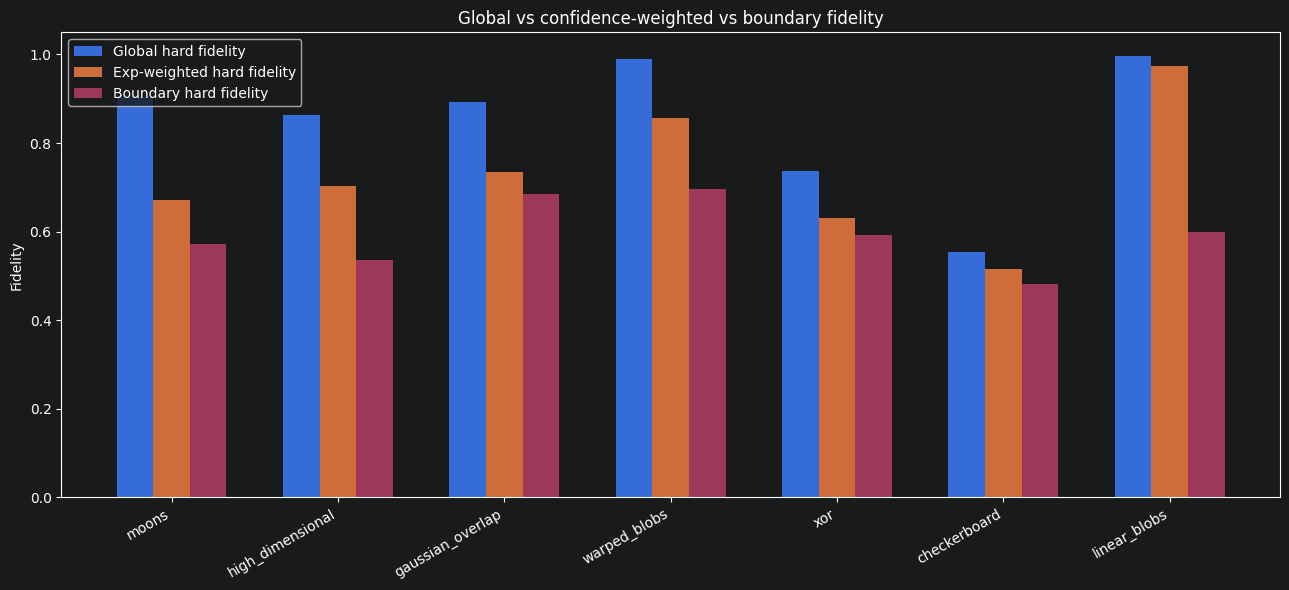

In [17]:
# -----------------------------------------------------------------------------
# Visual comparisons
# -----------------------------------------------------------------------------

ordered_datasets = dataset_summary.index.tolist()
positions = np.arange(len(ordered_datasets))
width = 0.22

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    positions - width,
    [dataset_summary.loc[d, "global_hard_mean"] for d in ordered_datasets],
    width,
    label="Global hard fidelity",
)
ax.bar(
    positions,
    [dataset_summary.loc[d, "exp_weighted_hard_mean"] for d in ordered_datasets],
    width,
    label="Exp-weighted hard fidelity",
)
ax.bar(
    positions + width,
    [dataset_summary.loc[d, "boundary_hard_mean"] for d in ordered_datasets],
    width,
    label="Boundary hard fidelity",
)
ax.set_xticks(positions)
ax.set_xticklabels(ordered_datasets, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fidelity")
ax.set_title("Global vs confidence-weighted vs boundary fidelity")
ax.legend()
plt.tight_layout()
plt.savefig("global_vs_weighted_vs_boundary_fidelity.png", dpi=200)
plt.show()


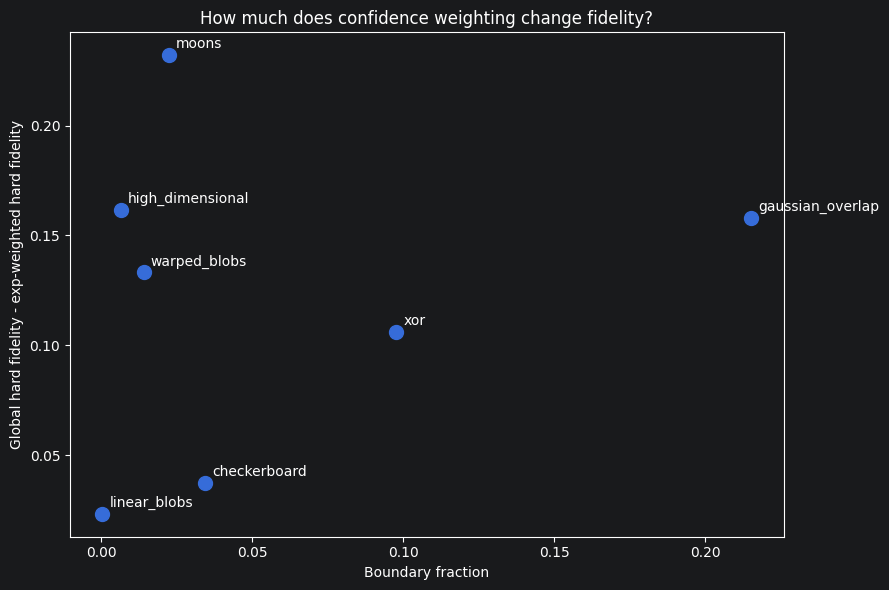

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    dataset_summary["boundary_fraction_mean"],
    dataset_summary["global_minus_exp_mean"],
    s=100,
)
for dataset_name, row in dataset_summary.iterrows():
    ax.annotate(dataset_name, (row["boundary_fraction_mean"], row["global_minus_exp_mean"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Boundary fraction")
ax.set_ylabel("Global hard fidelity - exp-weighted hard fidelity")
ax.set_title("How much does confidence weighting change fidelity?")
plt.tight_layout()
plt.savefig("weighted_shift_vs_boundary_fraction.png", dpi=200)
plt.show()


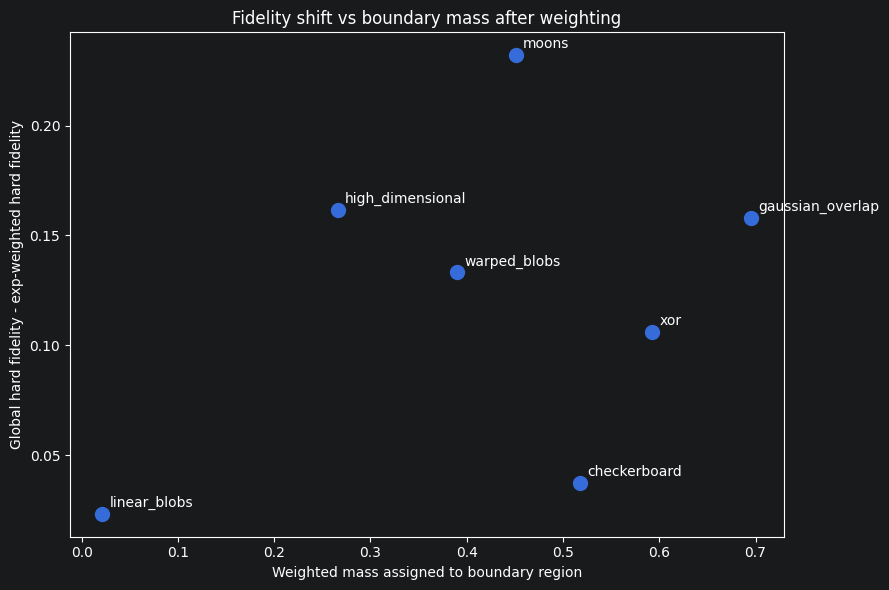

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    dataset_summary["exp_weight_mass_boundary_mean"],
    dataset_summary["global_minus_exp_mean"],
    s=100,
)
for dataset_name, row in dataset_summary.iterrows():
    ax.annotate(dataset_name, (row["exp_weight_mass_boundary_mean"], row["global_minus_exp_mean"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Weighted mass assigned to boundary region")
ax.set_ylabel("Global hard fidelity - exp-weighted hard fidelity")
ax.set_title("Fidelity shift vs boundary mass after weighting")
plt.tight_layout()
plt.savefig("weighted_shift_vs_weighted_boundary_mass.png", dpi=200)
plt.show()


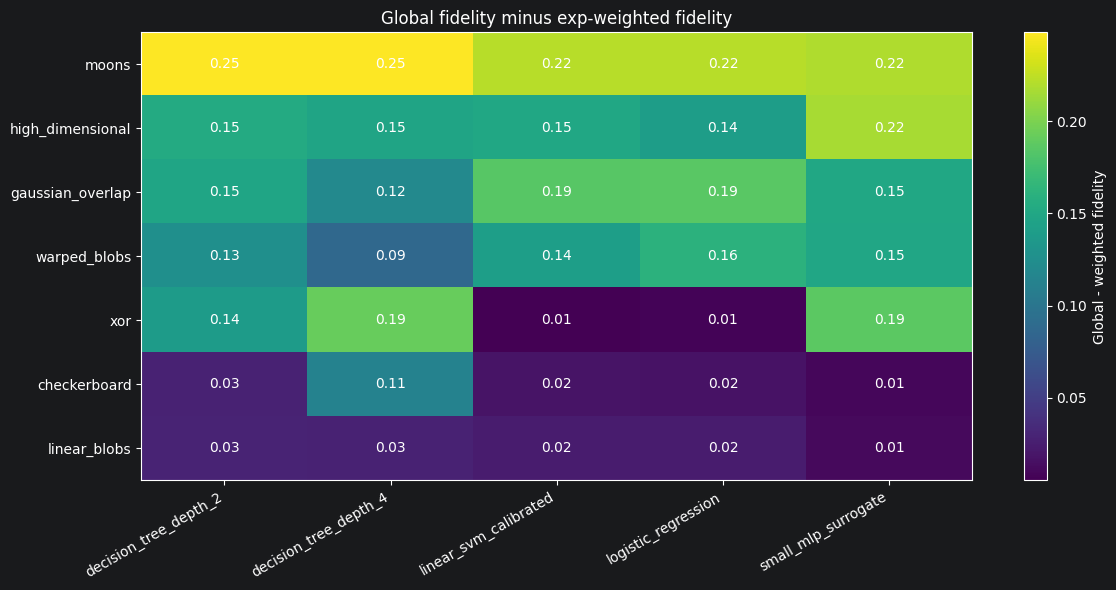

In [20]:
# Heatmap of how much weighting lowers hard fidelity, by dataset and surrogate.
shift_pivot = summary.pivot(index="dataset", columns="surrogate", values="global_minus_exp_mean")
shift_pivot = shift_pivot.loc[ordered_datasets]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(shift_pivot.values, aspect="auto")
ax.set_xticks(np.arange(shift_pivot.shape[1]))
ax.set_xticklabels(shift_pivot.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(shift_pivot.shape[0]))
ax.set_yticklabels(shift_pivot.index)
ax.set_title("Global fidelity minus exp-weighted fidelity")
for i in range(shift_pivot.shape[0]):
    for j in range(shift_pivot.shape[1]):
        ax.text(j, i, f"{shift_pivot.values[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Global - weighted fidelity")
plt.tight_layout()
plt.savefig("global_minus_weighted_fidelity_heatmap.png", dpi=200)
plt.show()


In [21]:
# -----------------------------------------------------------------------------
# Alpha/delta sweeps on selected datasets
# -----------------------------------------------------------------------------

selected_datasets = ["moons", "warped_blobs", "gaussian_overlap", "linear_blobs"]
selected_surrogates = ["logistic_regression", "small_mlp_surrogate"]
sweep_seeds = list(range(5))
alpha_values = [1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
delta_values = [0.005, 0.01, 0.02, 0.05, 0.10]

# To avoid retraining for every alpha/delta, cache predictions first.
prediction_cache = []
for dataset_name in selected_datasets:
    print(f"\n=== Cache predictions: {dataset_name} ===")
    for seed in sweep_seeds:
        X, y = load_dataset(dataset_name, n_samples=1500, random_state=seed)
        X = StandardScaler().fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.35, random_state=seed, stratify=y
        )
        teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)
        teacher_train_p = teacher_probs(teacher, X_train)
        teacher_train_y = (teacher_train_p >= 0.5).astype(int)
        teacher_test_p = teacher_probs(teacher, X_test)

        for surrogate_name in selected_surrogates:
            surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
            surrogate_test_p = surrogate_probs(surrogate, X_test)
            prediction_cache.append({
                "dataset": dataset_name,
                "seed": seed,
                "surrogate": surrogate_name,
                "y_test": y_test,
                "teacher_test_p": teacher_test_p,
                "surrogate_test_p": surrogate_test_p,
            })



=== Cache predictions: moons ===

=== Cache predictions: warped_blobs ===

=== Cache predictions: gaussian_overlap ===

=== Cache predictions: linear_blobs ===


In [22]:
sweep_rows = []
for item in prediction_cache:
    for alpha in alpha_values:
        row = compute_all_metrics(
            item["y_test"],
            item["teacher_test_p"],
            item["surrogate_test_p"],
            eps=0.10,
            alpha=alpha,
            delta=0.02,
        )
        row["dataset"] = item["dataset"]
        row["seed"] = item["seed"]
        row["surrogate"] = item["surrogate"]
        row["sweep_type"] = "alpha"
        row["sweep_value"] = alpha
        sweep_rows.append(row)

    for delta in delta_values:
        row = compute_all_metrics(
            item["y_test"],
            item["teacher_test_p"],
            item["surrogate_test_p"],
            eps=0.10,
            alpha=10.0,
            delta=delta,
        )
        row["dataset"] = item["dataset"]
        row["seed"] = item["seed"]
        row["surrogate"] = item["surrogate"]
        row["sweep_type"] = "delta"
        row["sweep_value"] = delta
        sweep_rows.append(row)

sweep_results = pd.DataFrame(sweep_rows)
sweep_results


,teacher_task_accuracy,surrogate_task_accuracy,global_hard_fidelity,global_soft_fidelity,probability_mse,boundary_fraction,n_boundary_points,exp_alpha,inv_delta,exp_weight_mass_boundary,...,inv_weighted_soft_fidelity,global_minus_exp_weighted_hard,global_minus_inv_weighted_hard,global_minus_exp_weighted_soft,global_minus_inv_weighted_soft,dataset,seed,surrogate,sweep_type,sweep_value
0,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,1.0,0.020,0.029057,...,0.805468,0.011371,0.049193,0.007714,0.051456,moons,0,logistic_regression,alpha,1.000
1,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,2.0,0.020,0.043787,...,0.805468,0.024894,0.049193,0.017306,0.051456,moons,0,logistic_regression,alpha,2.000
2,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,5.0,0.020,0.133585,...,0.805468,0.078195,0.049193,0.059820,0.051456,moons,0,logistic_regression,alpha,5.000
3,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,10.0,0.020,0.455201,...,0.805468,0.159682,0.049193,0.151886,0.051456,moons,0,logistic_regression,alpha,10.000
4,0.914286,0.840000,0.883810,0.856923,0.059355,0.019048,10,20.0,0.020,0.868347,...,0.805468,0.149567,0.049193,0.203792,0.051456,moons,0,logistic_regression,alpha,20.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.992381,0.990476,0.994286,0.976078,0.004248,0.000000,0,10.0,0.005,0.000000,...,0.974844,0.024857,0.002588,0.010500,0.001234,linear_blobs,4,small_mlp_surrogate,delta,0.005
436,0.992381,0.990476,0.994286,0.976078,0.004248,0.000000,0,10.0,0.010,0.000000,...,0.974863,0.024857,0.002544,0.010500,0.001215,linear_blobs,4,small_mlp_surrogate,delta,0.010
437,0.992381,0.990476,0.994286,0.976078,0.004248,0.000000,0,10.0,0.020,0.000000,...,0.974898,0.024857,0.002462,0.010500,0.001180,linear_blobs,4,small_mlp_surrogate,delta,0.020
438,0.992381,0.990476,0.994286,0.976078,0.004248,0.000000,0,10.0,0.050,0.000000,...,0.974992,0.024857,0.002245,0.010500,0.001086,linear_blobs,4,small_mlp_surrogate,delta,0.050


In [23]:
sweep_results.to_csv("confidence_weighted_fidelity_parameter_sweep_raw.csv", index=False)
print("Saved confidence_weighted_fidelity_parameter_sweep_raw.csv")


Saved confidence_weighted_fidelity_parameter_sweep_raw.csv


In [24]:
sweep_summary = (
    sweep_results
    .groupby(["dataset", "surrogate", "sweep_type", "sweep_value"])
    .agg(
        global_hard_mean=("global_hard_fidelity", "mean"),
        exp_weighted_hard_mean=("exp_weighted_hard_fidelity", "mean"),
        inv_weighted_hard_mean=("inv_weighted_hard_fidelity", "mean"),
        boundary_hard_mean=("boundary_hard_fidelity", "mean"),
        global_minus_exp_mean=("global_minus_exp_weighted_hard", "mean"),
        global_minus_inv_mean=("global_minus_inv_weighted_hard", "mean"),
        exp_weight_mass_boundary_mean=("exp_weight_mass_boundary", "mean"),
        inv_weight_mass_boundary_mean=("inv_weight_mass_boundary", "mean"),
    )
    .reset_index()
)

sweep_summary


,dataset,surrogate,sweep_type,sweep_value,global_hard_mean,exp_weighted_hard_mean,inv_weighted_hard_mean,boundary_hard_mean,global_minus_exp_mean,global_minus_inv_mean,exp_weight_mass_boundary_mean,inv_weight_mass_boundary_mean
0,gaussian_overlap,logistic_regression,alpha,1.000,0.844571,0.820667,0.695221,0.576683,0.023905,0.149351,0.241527,0.551734
1,gaussian_overlap,logistic_regression,alpha,2.000,0.844571,0.796140,0.695221,0.576683,0.048431,0.149351,0.293566,0.551734
2,gaussian_overlap,logistic_regression,alpha,5.000,0.844571,0.727584,0.695221,0.576683,0.116987,0.149351,0.452243,0.551734
3,gaussian_overlap,logistic_regression,alpha,10.000,0.844571,0.650317,0.695221,0.576683,0.194254,0.149351,0.659026,0.551734
4,gaussian_overlap,logistic_regression,alpha,20.000,0.844571,0.581069,0.695221,0.576683,0.263503,0.149351,0.866731,0.551734
...,...,...,...,...,...,...,...,...,...,...,...,...
83,warped_blobs,small_mlp_surrogate,delta,0.005,0.992381,0.876736,0.958784,0.780897,0.115645,0.033597,0.479384,0.221522
84,warped_blobs,small_mlp_surrogate,delta,0.010,0.992381,0.876736,0.962074,0.780897,0.115645,0.030307,0.479384,0.183104
85,warped_blobs,small_mlp_surrogate,delta,0.020,0.992381,0.876736,0.966412,0.780897,0.115645,0.025969,0.479384,0.144637
86,warped_blobs,small_mlp_surrogate,delta,0.050,0.992381,0.876736,0.973293,0.780897,0.115645,0.019087,0.479384,0.098278


In [25]:
sweep_summary.to_csv("confidence_weighted_fidelity_parameter_sweep_summary.csv", index=False)
print("Saved confidence_weighted_fidelity_parameter_sweep_summary.csv")


Saved confidence_weighted_fidelity_parameter_sweep_summary.csv


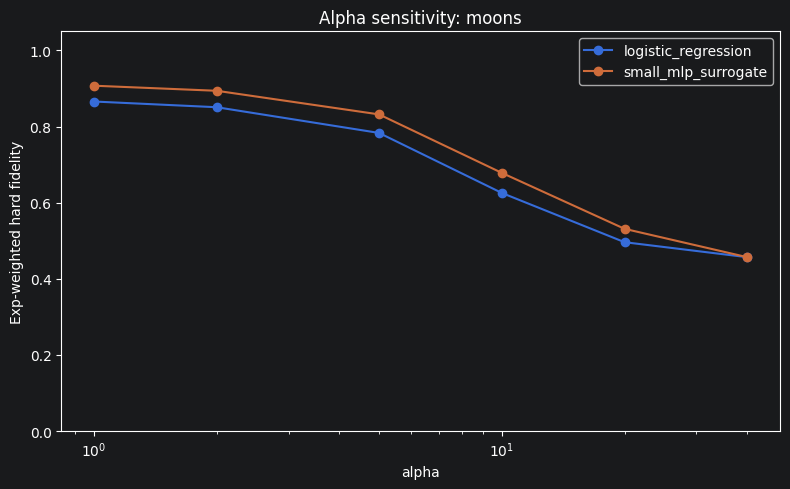

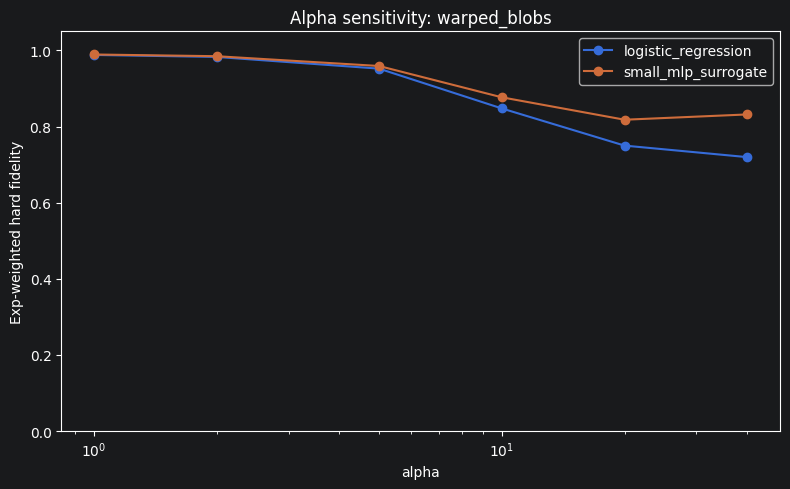

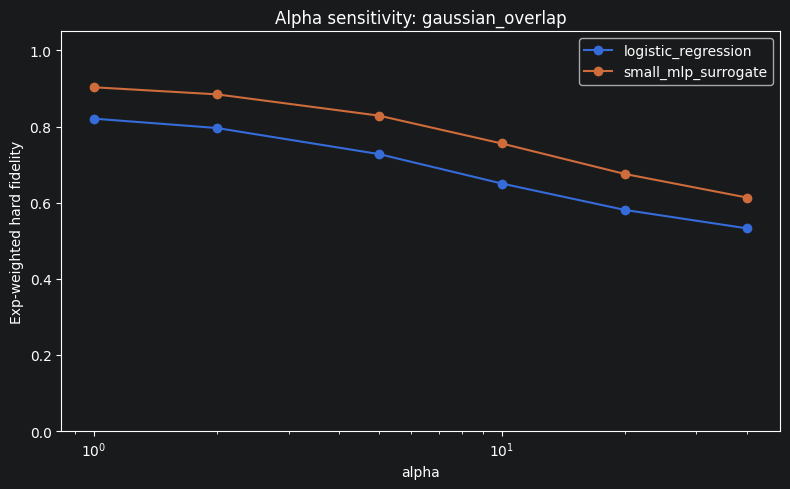

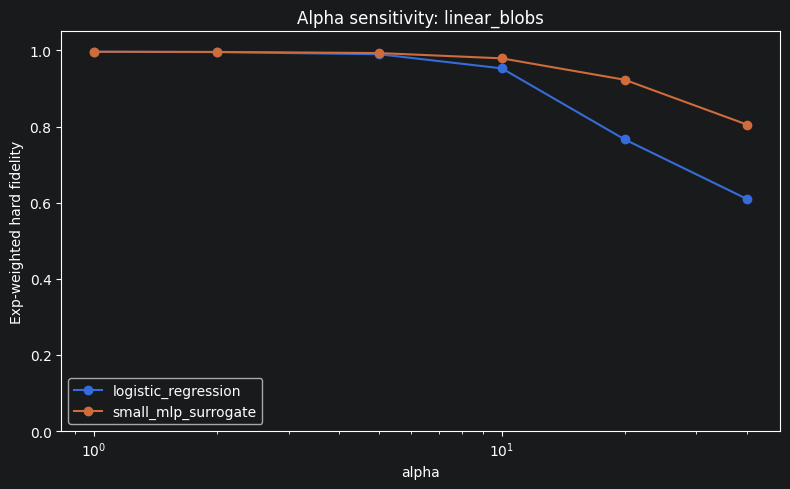

In [26]:
# Plot alpha sensitivity for exponential weighting.
alpha_summary = sweep_summary[sweep_summary["sweep_type"] == "alpha"]

for dataset_name in selected_datasets:
    fig, ax = plt.subplots(figsize=(8, 5))
    for surrogate_name in selected_surrogates:
        subset = alpha_summary[
            (alpha_summary["dataset"] == dataset_name)
            & (alpha_summary["surrogate"] == surrogate_name)
        ].sort_values("sweep_value")
        ax.plot(
            subset["sweep_value"],
            subset["exp_weighted_hard_mean"],
            marker="o",
            label=surrogate_name,
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("alpha")
    ax.set_ylabel("Exp-weighted hard fidelity")
    ax.set_title(f"Alpha sensitivity: {dataset_name}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"alpha_sensitivity_{dataset_name}.png", dpi=200)
    plt.show()


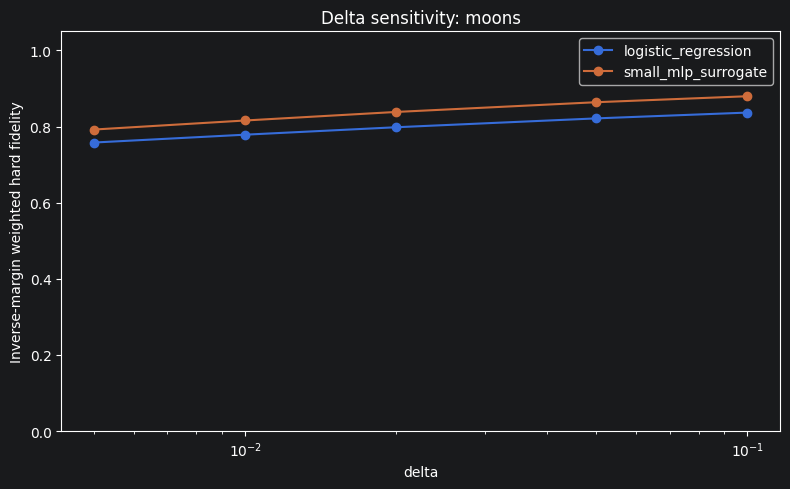

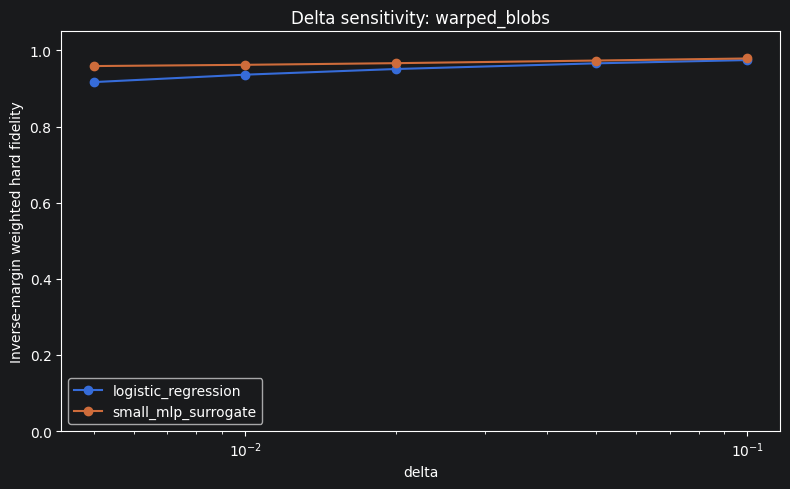

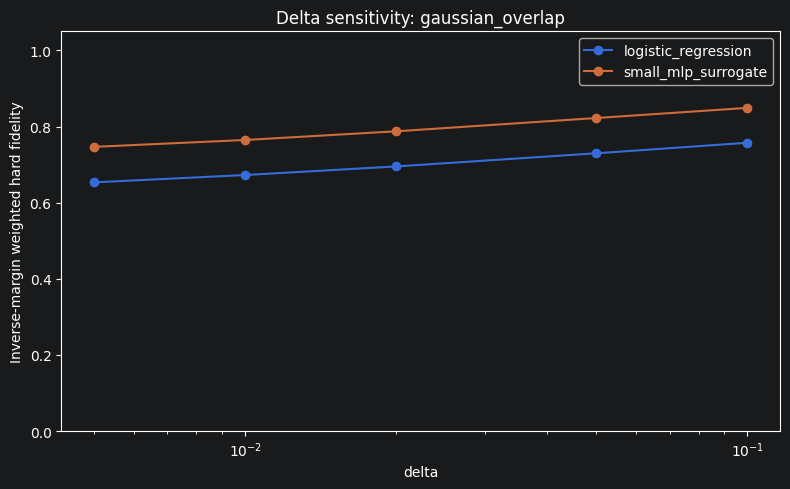

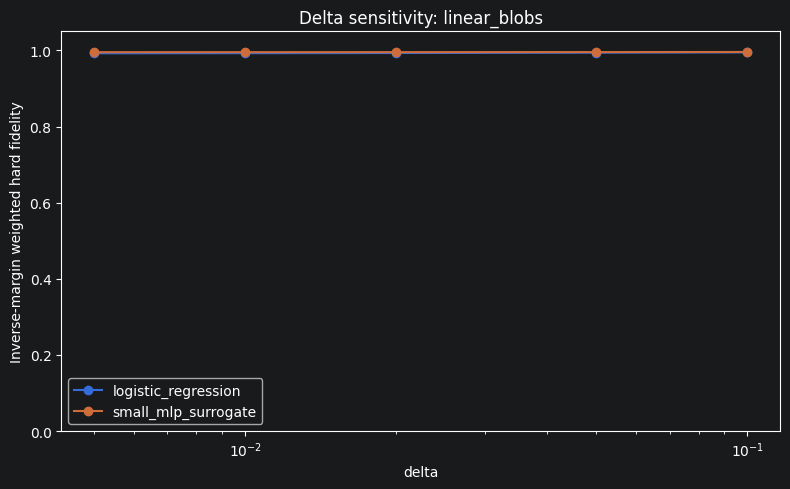

In [27]:
# Plot delta sensitivity for inverse-margin weighting.
delta_summary = sweep_summary[sweep_summary["sweep_type"] == "delta"]

for dataset_name in selected_datasets:
    fig, ax = plt.subplots(figsize=(8, 5))
    for surrogate_name in selected_surrogates:
        subset = delta_summary[
            (delta_summary["dataset"] == dataset_name)
            & (delta_summary["surrogate"] == surrogate_name)
        ].sort_values("sweep_value")
        ax.plot(
            subset["sweep_value"],
            subset["inv_weighted_hard_mean"],
            marker="o",
            label=surrogate_name,
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("delta")
    ax.set_ylabel("Inverse-margin weighted hard fidelity")
    ax.set_title(f"Delta sensitivity: {dataset_name}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"delta_sensitivity_{dataset_name}.png", dpi=200)
    plt.show()


In [28]:
# -----------------------------------------------------------------------------
# Ranking comparison
# -----------------------------------------------------------------------------
# Does weighting change which surrogate appears best?

ranking_rows = []
for dataset_name, group in summary.groupby("dataset"):
    for metric in [
        "global_hard_mean",
        "exp_weighted_hard_mean",
        "inv_weighted_hard_mean",
        "boundary_hard_mean",
    ]:
        ranked = group[["surrogate", metric]].sort_values(metric, ascending=False).reset_index(drop=True)
        for rank, row in ranked.iterrows():
            ranking_rows.append({
                "dataset": dataset_name,
                "metric": metric,
                "rank": rank + 1,
                "surrogate": row["surrogate"],
                "score": row[metric],
            })

rankings = pd.DataFrame(ranking_rows)
rankings


,dataset,metric,rank,surrogate,score
0,checkerboard,global_hard_mean,1,decision_tree_depth_4,0.662857
1,checkerboard,global_hard_mean,2,decision_tree_depth_2,0.541714
2,checkerboard,global_hard_mean,3,small_mlp_surrogate,0.528571
3,checkerboard,global_hard_mean,4,linear_svm_calibrated,0.523810
4,checkerboard,global_hard_mean,5,logistic_regression,0.510095
...,...,...,...,...,...
135,xor,boundary_hard_mean,1,small_mlp_surrogate,0.673798
136,xor,boundary_hard_mean,2,decision_tree_depth_4,0.671636
137,xor,boundary_hard_mean,3,decision_tree_depth_2,0.543914
138,xor,boundary_hard_mean,4,linear_svm_calibrated,0.539855


In [29]:
rankings.to_csv("confidence_weighted_fidelity_rankings.csv", index=False)
print("Saved confidence_weighted_fidelity_rankings.csv")


Saved confidence_weighted_fidelity_rankings.csv


In [30]:
# Top-surrogate comparison by metric.
top_surrogates = rankings[rankings["rank"] == 1].pivot(index="dataset", columns="metric", values="surrogate")
top_surrogates


metric,boundary_hard_mean,exp_weighted_hard_mean,global_hard_mean,inv_weighted_hard_mean
dataset,,,,
checkerboard,small_mlp_surrogate,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4
gaussian_overlap,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4
high_dimensional,decision_tree_depth_4,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate
linear_blobs,small_mlp_surrogate,small_mlp_surrogate,linear_svm_calibrated,small_mlp_surrogate
moons,small_mlp_surrogate,small_mlp_surrogate,decision_tree_depth_2,small_mlp_surrogate
warped_blobs,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4
xor,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate


In [31]:
top_surrogates.to_csv("confidence_weighted_fidelity_top_surrogates.csv")
print("Saved confidence_weighted_fidelity_top_surrogates.csv")


Saved confidence_weighted_fidelity_top_surrogates.csv


In [32]:
print("Questions this notebook answers:")
print("1. Does confidence weighting lower fidelity relative to global fidelity?")
print("2. Does weighting move scores toward boundary fidelity without using a hard boundary cutoff?")
print("3. Does weighting change surrogate rankings?")
print("4. How sensitive are weighted metrics to alpha/delta?")
print("5. Does this motivate a later geometric-distance version of the metric?")


Questions this notebook answers:
1. Does confidence weighting lower fidelity relative to global fidelity?
2. Does weighting move scores toward boundary fidelity without using a hard boundary cutoff?
3. Does weighting change surrogate rankings?
4. How sensitive are weighted metrics to alpha/delta?
5. Does this motivate a later geometric-distance version of the metric?
